In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(transform_output="pandas")

df = pd.read_excel("../data/moscow_transformed.xlsx").set_index(["ID на сайте", "Источник"])
df = df[["Цена", "lat", "lng", "Общая площадь", "Расстояние до метро, км", "Этаж", "Тип автора", "Вид объекта", "Метро/Район"]].copy()
df.columns = ["price", "lat", "lon", "square", "metro_dist", "floor", "author_type", "object_type", "metro_district"]
df = df.dropna(subset="object_type")
df.head()

,,price,lat,lon,square,metro_dist,floor,author_type,object_type,metro_district
ID на сайте,Источник,,,,,,,,,
320731003,cian.ru,38800,55.621211,37.745600,25.0,0.083,4.0,Агентство,Офисное помещение,Шипиловская
321876001,cian.ru,31250,55.799036,37.532601,25.0,0.250,-2.0,Агентство,Офисное помещение,Аэропорт
322186790,cian.ru,29200,55.731176,37.669279,20.0,0.250,6.0,Агентство,Офисное помещение,Пролетарская
321392086,cian.ru,32000,55.540409,37.516153,32.0,0.250,3.0,Частное лицо,Торговое / Свободного назначения,Бунинская Аллея
324943206,cian.ru,44000,55.808002,37.635853,24.0,0.167,14.0,Агентство,Офисное помещение,Алексеевская


In [2]:
df.dtypes

price               int64
lat               float64
lon               float64
square            float64
metro_dist        float64
floor             float64
author_type        object
object_type        object
metro_district     object
dtype: object

In [3]:
df.isna().sum()

price               0
lat                 0
lon                 0
square              0
metro_dist          0
floor             123
author_type         0
object_type         0
metro_district      0
dtype: int64

In [4]:
df["metro_district"].nunique()

315

In [5]:
from sklearn.model_selection import train_test_split

y = df["price"].copy()
df = df.drop("price", axis=1)

df_train, df_test, y_train, y_test = train_test_split(df, y, test_size=0.25, stratify=df["object_type"])

In [6]:
df_train["floor"] = df_train["floor"].fillna(1)
df_test["floor"] = df_test["floor"].fillna(1)

# Pipeline

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


class OrdinalByTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.te = TargetEncoder(target_type="continuous", random_state=10)

    def fit(self, X, y):
        self.te = self.te.fit(X, y)
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        for i, col in enumerate(X.columns):
            cat_dict = dict(zip(self.te.categories_[i], self.te.encodings_[i]))
            ordinal_categories = sorted(cat_dict, key=cat_dict.get)
            ordinal_mapping = dict(zip(ordinal_categories, range(len(ordinal_categories))))
            X_copy[col] = X_copy[col].map(ordinal_mapping)
            # Заполним пропуски центральным значением (медианой)
            X_copy[col] = X_copy[col].fillna(len(ordinal_categories) // 2)
        return X_copy

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def set_output(self, *, transform=None):
        """Scikit-learn 1.2+ requirement"""
        return self


def make_transformer(
            scale_cols: list,
            one_hot_cols: list,
            ordinal_cols: list,
            **kwargs
    ):
    ct = ColumnTransformer(
        transformers=[
            ("scale", StandardScaler(), scale_cols),
            ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), one_hot_cols),
            ("ordinal", OrdinalByTargetEncoder(), ordinal_cols),
        ],
        **kwargs
    ).set_output(transform="pandas")
    return ct

def make_pipeline(
        model,
        scale_cols: list,
        one_hot_cols: list,
        ordinal_cols: list,
        **kwargs
    ):

    ct = make_transformer(scale_cols, one_hot_cols, ordinal_cols, **kwargs)

    pipe = Pipeline(
        steps=[
            ("transformer", ct),
            ("model", model),
        ]
    )

    return pipe

# Модель

In [8]:
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

def print_metrics(y_true, y_pred, dataset):
    print(f"{dataset} metrics:")
    print(f"\t  R2: {r2_score(y_true, y_pred) * 100:.2f}%")
    print(f"\tRMSE: {rmse(y_true, y_pred):.2f} руб.")
    print(f"\tMAPE: {mape(y_true, y_pred) * 100:.2f}%")

In [9]:
import sys
sys.path.append("..")

import viz

## Линейка

In [10]:
scale_cols = ["square", "metro_dist", "floor"]
one_hot_cols = ["object_type", "author_type"]
ordinal_cols = ["metro_district"]

linear_pipe = make_pipeline(
    LinearRegression(),
    scale_cols, one_hot_cols, ordinal_cols,
    remainder="passthrough", n_jobs=-1)

linear_pipe

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scale', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


train metrics:
	  R2: 72.74%
	RMSE: 754016.72 руб.
	MAPE: 93.00%

test metrics:
	  R2: 73.41%
	RMSE: 730897.09 руб.
	MAPE: 95.22%


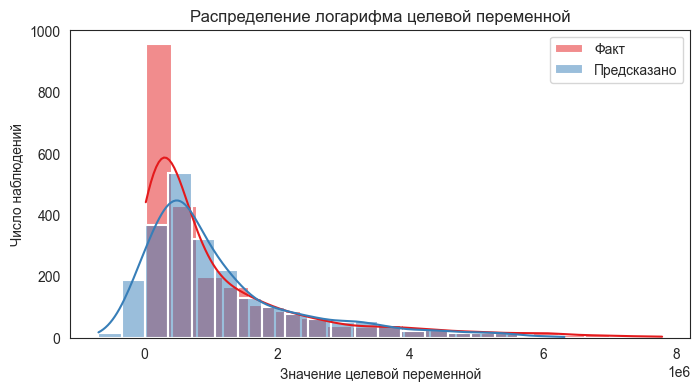

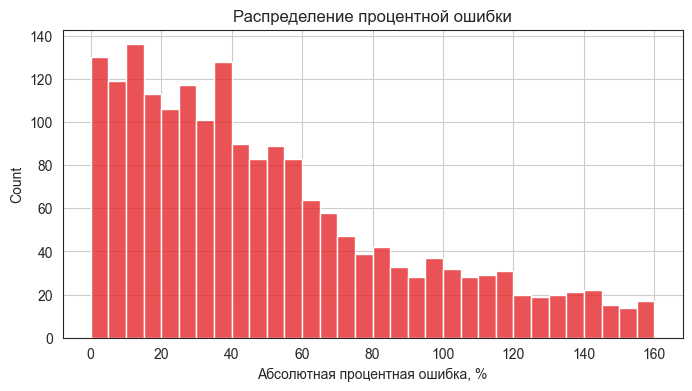

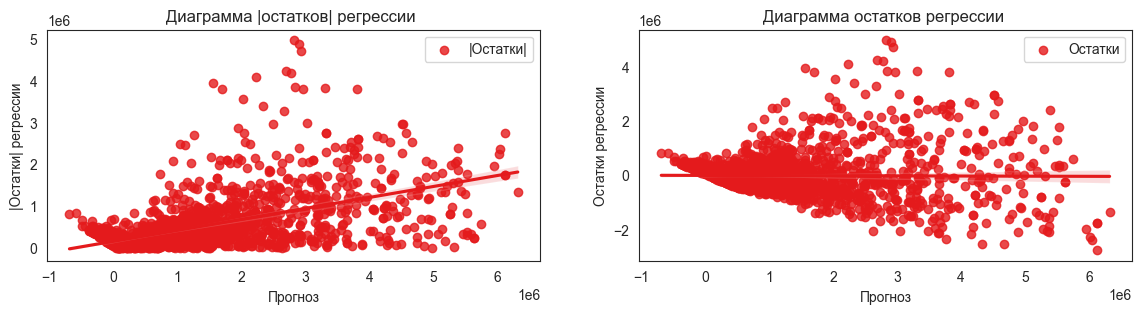

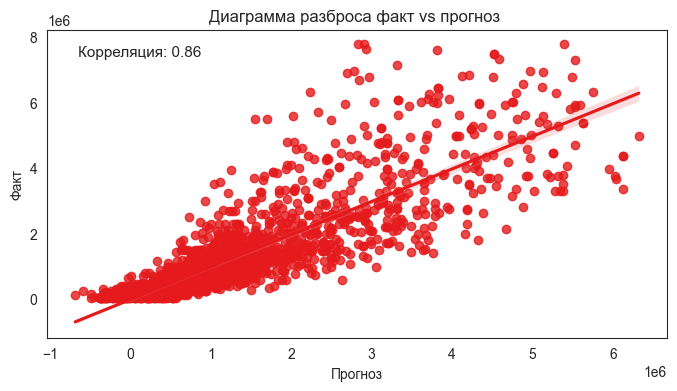

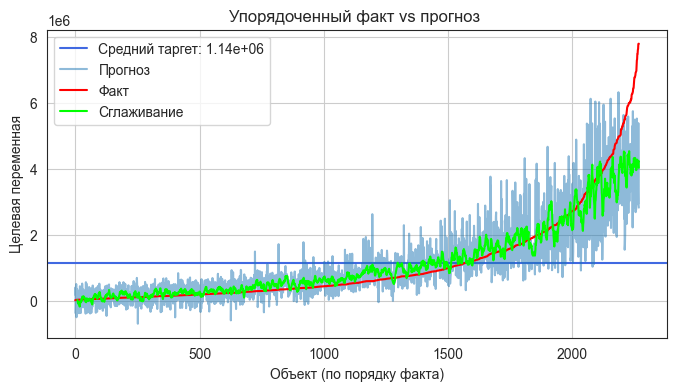

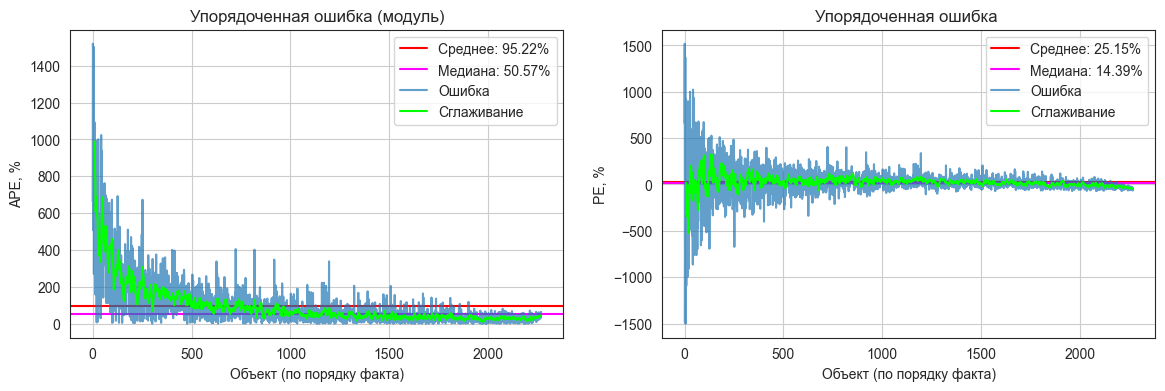

In [11]:
model = linear_pipe.fit(df_train, y_train)
y_pred = model.predict(df_train)
y_test_pred = model.predict(df_test)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

In [12]:
import os
from dotenv import load_dotenv

assert load_dotenv("C:/Users/Oleg/Desktop/sirius-school-proj/service/.env")
os.environ.get("MLFLOW_TRACKING_URI")

'https://sirius-mlflow.onrender.com'

In [13]:
import mlflow

MLFLOW_EXP = "moscow-rent-model-lr"
try:
    mlflow.create_experiment(name=MLFLOW_EXP)
except:
    pass
mlflow.set_experiment(MLFLOW_EXP)

C:\Users\Oleg\miniconda3\envs\sirius\lib\site-packages\mlflow\utils\requirements_utils.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<Experiment: artifact_location='mlflow-artifacts:/116677003744854467', creation_time=1766652592869, experiment_id='116677003744854467', last_update_time=1766652592869, lifecycle_stage='active', name='moscow-rent-model-lr', tags={}>

In [14]:
metrics = {
    "Train R2": r2_score(y_train, y_pred),
    "Train RMSE": rmse(y_train, y_pred),
    "Train MAPE": mape(y_train, y_pred),
    "Test R2": r2_score(y_test, y_test_pred),
    "Test RMSE": rmse(y_test, y_test_pred),
    "Test MAPE": mape(y_test, y_test_pred),
}

metrics

{'Train R2': 0.7273910220960181,
 'Train RMSE': 754016.7183642605,
 'Train MAPE': 0.9300383672304084,
 'Test R2': 0.7341371218103222,
 'Test RMSE': 730897.0874371473,
 'Test MAPE': 0.9522328388244534}

In [20]:
linear_pipe.steps[1][1].get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [21]:
from mlflow.models import infer_signature


run_description = """Moscow rent prediction regression model (linear, OLS)"""
with mlflow.start_run(run_name="model-linear-v1", description=run_description):
    signature = infer_signature(df_train, y_pred)
    mlflow.sklearn.log_model(
        linear_pipe, "model",
        signature=signature,
        input_example=df_train.sample(),
    )

    mlflow.log_params(linear_pipe.steps[1][1].get_params())
    mlflow.log_metrics(metrics)

2025/12/25 12:00:32 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Oleg\AppData\Local\Temp\tmpatqwqrwp\model\model.pkl, flavor: sklearn), fall back to return ['scikit-learn==1.7.2', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback.


In [22]:
mlflow.sklearn.load_model("models:/moscow-rent/Production").predict(df_test)

array([1750028.93260979, 4174716.40189716,   99332.41044804, ...,
       3116314.82170171,   92743.60829582,  523857.64463125])